In this notebook, we aim to **replicate the results** obtained by *Walasek and Gajda* in the paper  
**"Fractional Differentiation and its Use in Machine Learning"**.


# Downloading data

In [ ]:
# ⚙️ Run this cell only once to download and save the data.
# After this, you can skip it and directly load the CSV files.

import yfinance as yf

start_date = "2010-06-01"
end_date = "2020-06-30"

# Download data (each index in its own DataFrame)
sp500_data  = yf.download('^GSPC',  start=start_date, end=end_date)
wig20_data  = yf.download('^WIG20', start=start_date, end=end_date)
dax_data    = yf.download('^GDAXI', start=start_date, end=end_date)
nikkei_data = yf.download('^N225',  start=start_date, end=end_date)

# Save the data as CSV files
sp500_data.to_csv("sp500_data.csv")
wig20_data.to_csv("wig20_data.csv")
dax_data.to_csv("dax_data.csv")
nikkei_data.to_csv("nikkei_data.csv")


# ▶️ Starting point

If you already have the historical data for the four indices saved as CSV files, you can **skip the previous cell** and start running from here.


In [1]:
# === Importing required libraries ===
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
from fracdiff.sklearn import Fracdiff


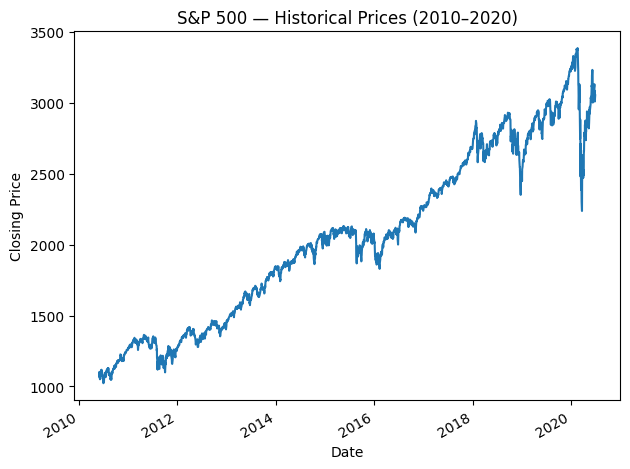

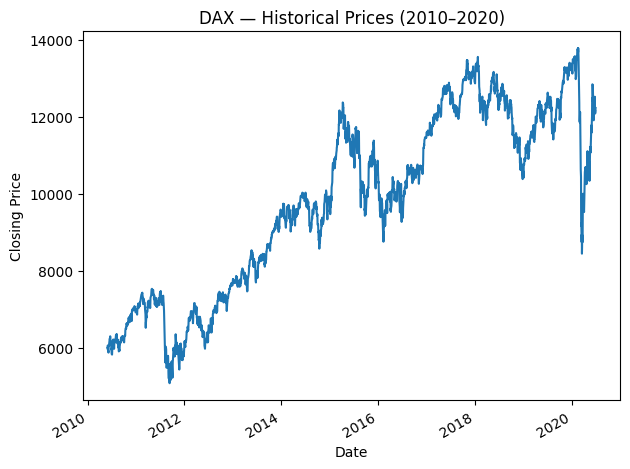

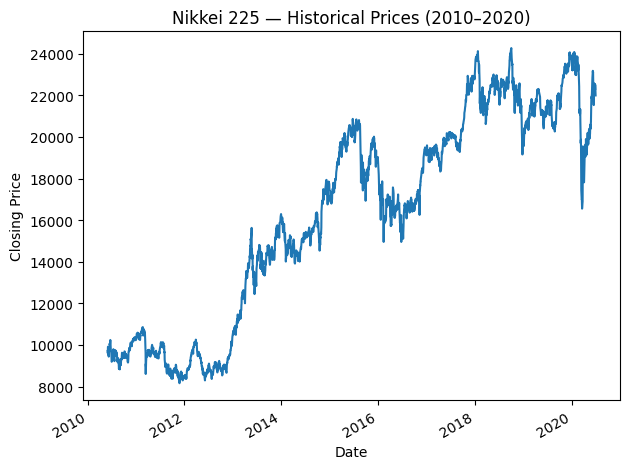

In [2]:
# === Read CSV files and clean them ===
def reading_file(file_name):
    data = pd.read_csv(
        file_name,
        header=[0, 1],        # 2 header rows: ('Price', 'Ticker')
        index_col=0,          # first column is the date index
        parse_dates=True,
    )
    # Keep only the first level of the columns ('Price')
    data.columns = data.columns.get_level_values(0)
    # Ensure all entries are numeric
    data = data.apply(pd.to_numeric, errors="coerce")
    return data


# WIG20 is excluded since its data start only from 2013-03-05 (without clear reason)
sp500 = reading_file("sp500_data.csv")
dax = reading_file("dax_data.csv")
nikkei = reading_file("nikkei_data.csv")

# Plot each index
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    df["Close"].plot(title=f"{name} — Historical Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("Closing Price")
    plt.tight_layout()
    plt.show()


In the following, we analyze the **stationarity** of the time series by applying **unit root tests** such as *ADF* and *KPSS*.


In [3]:
# === ADF & KPSS tests ===
def stationarity_values(series):
    series = series.dropna()
    a_stat, a_p, *_ = adfuller(series, autolag="AIC")
    k_stat, k_p, *_ = kpss(series, regression="c", nlags="auto")
    return a_stat, a_p, k_stat, k_p


results = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close"])
    results.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table = pd.DataFrame(results, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table.style.set_properties(**{'white-space': 'pre-wrap'}))




/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


,ADF,KPSS
Stock index,,
S&P 500,-0.76 (0.83),8.03 (0.01)
DAX,-1.67 (0.45),7.33 (0.01)
Nikkei 225,-1.20 (0.67),7.32 (0.01)


### 📊 Stationarity Tests: ADF vs KPSS

<div style="display: flex; justify-content: space-between; gap: 2rem;">

<div style="flex: 1;">

#### 🔹 Augmented Dickey–Fuller (ADF)
- **H₀:** the series has a *unit root* → **non-stationary**  
- **H₁:** the series is **stationary**

| Result | Interpretation |
|:--------|:----------------|
| ✅ Accept H₀ | → Series is **non-stationary** |
| ❌ Reject H₀ | → Series is **stationary** |

</div>

<div style="flex: 1;">

#### 🔹 Kwiatkowski–Phillips–Schmidt–Shin (KPSS)
- **H₀:** the series is *(trend-)stationary*  
- **H₁:** the series is **non-stationary**

| Result | Interpretation |
|:--------|:----------------|
| ✅ Accept H₀ | → Series is **stationary** |
| ❌ Reject H₀ | → Series is **non-stationary** |

</div>
</div>

#### 💡 About the *p-value*
- The **p-value** indicates the probability of observing the test statistic *under the null hypothesis*:
  - **p-value < 0.05** → **Reject H₀**
  - **p-value ≥ 0.05** → **Accept H₀**
- Hence:
  - For **ADF**, a small p-value (< 0.05) ⇒ reject H₀ ⇒ **stationary series**  
  - For **KPSS**, a small p-value (< 0.05) ⇒ reject H₀ ⇒ **non-stationary series**
- Extremely small p-values in KPSS (sometimes triggering warnings) mean the series is **strongly non-stationary** —  
  the test statistic lies beyond the available critical values.

---

- If both tests suggest non-stationarity → apply (fractional) **differencing**.


> **Remark.** The three indices don’t share exactly the same trading calendar — holidays/timezones lead to **different date lengths** and missing days per index. That’s normal for international markets.  


## Differentiating the time series

In what follows we apply **integer** and **fractional** differencing to obtain
(time-)**stationary** series better suited for forecasting.

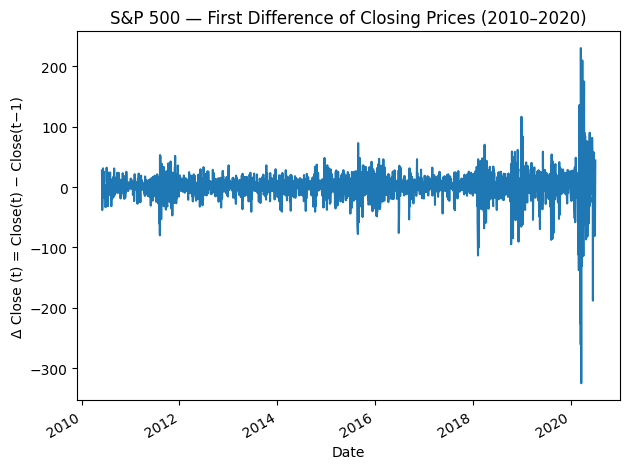

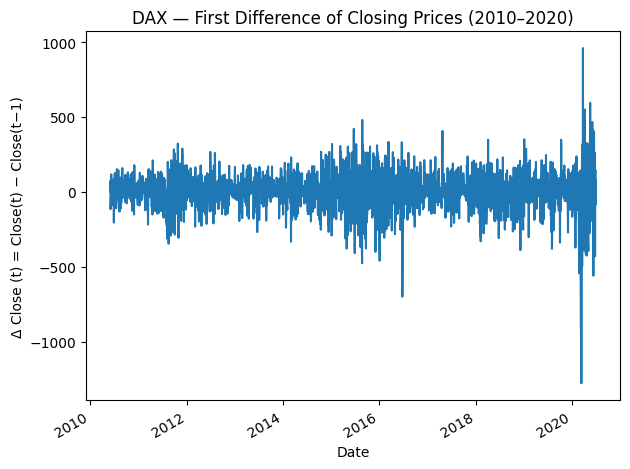

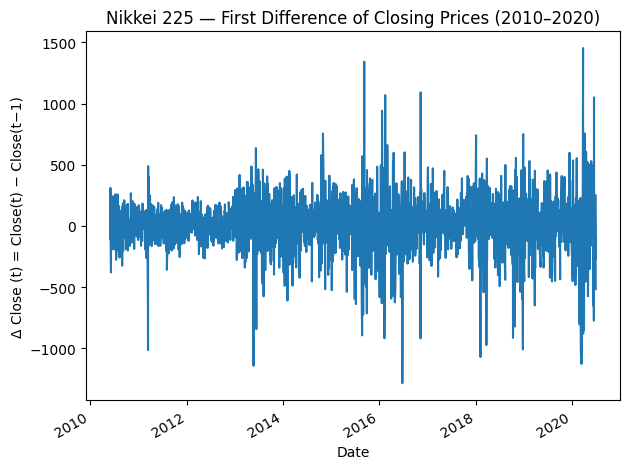

In [4]:
# === Integer differencing (d = 1) ===
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    df["Close_diff"] = df["Close"].diff()
    df["Close_diff"].plot(title=f"{name} — First Difference of Closing Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("Δ Close (t) = Close(t) − Close(t−1)")
    plt.tight_layout()
    plt.show()

In [5]:
# === ADF & KPSS on the differenced series (quick check) ===


results_diff = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_diff"])
    results_diff.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_diff = pd.DataFrame(results_diff, columns=["Stock index", "ADF (Δ)", "KPSS (Δ)"]).set_index("Stock index")
display(table_diff.style.set_properties(**{'white-space': 'pre-wrap'}))

/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


,ADF (Δ),KPSS (Δ)
Stock index,,
S&P 500,-11.13 (0.00),0.01 (0.10)
DAX,-17.56 (0.00),0.04 (0.10)
Nikkei 225,-33.71 (0.00),0.04 (0.10)


As expected, the **first difference** (d = 1) yields (near-)stationary series. The ADF statistic typically moves from around **−1/−2** to **−20/−30**, indicating strong evidence against a unit root. This suggests that a **fractional** order might suffice to reach stationarity while **preserving more memory** than d = 1.


## Fractional Differentiation

We now apply **fractional differencing** to the closing prices.  
Our goal is to obtain (near-)stationarity while retaining as much memory of the original series as possible.  
We will start by applying the exact fractional orders reported in the paper, then visualize and test the resulting series.


In [6]:
# === Fractional Differencing (using the same orders as in the reference paper) ===

# S&P 500 — d = 0.43
fracdiff_sp500 = Fracdiff(0.43)
X_sp500 = sp500[['Close']]
sp500_fd = fracdiff_sp500.fit_transform(X_sp500)
sp500['Close_fd'] = pd.Series(sp500_fd.ravel(), index=sp500.index)

# DAX — d = 0.28
fracdiff_dax = Fracdiff(0.28)
X_dax = dax[['Close']]
dax_fd = fracdiff_dax.fit_transform(X_dax)
dax['Close_fd'] = pd.Series(dax_fd.ravel(), index=dax.index)

# Nikkei 225 — d = 0.35
fracdiff_nikkei = Fracdiff(0.35)
X_nikkei = nikkei[['Close']]
nikkei_fd = fracdiff_nikkei.fit_transform(X_nikkei)
nikkei['Close_fd'] = pd.Series(nikkei_fd.ravel(), index=nikkei.index)



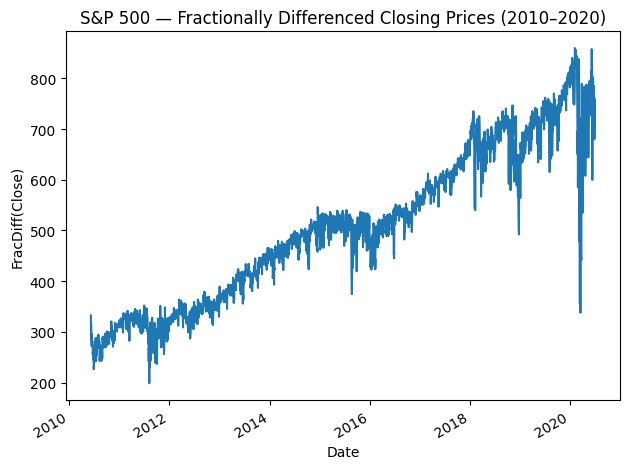

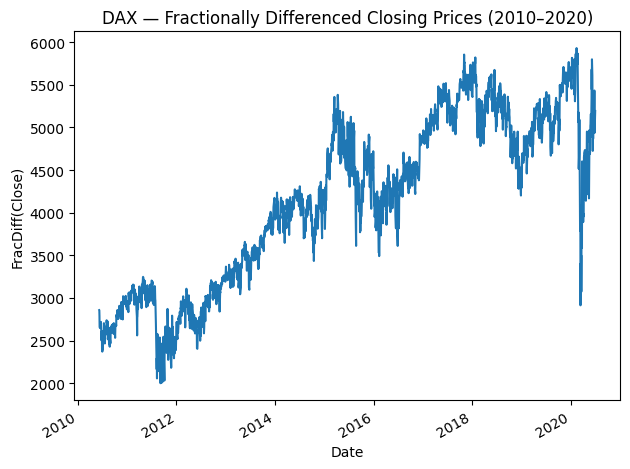

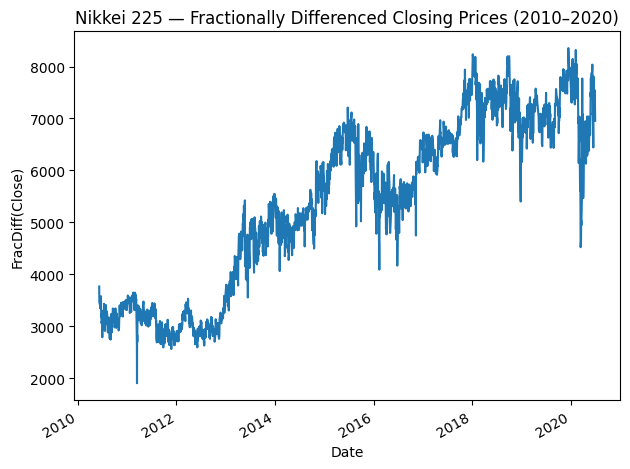

In [7]:
# === Plot fractionally differenced series ===
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    # Skip first few NaNs due to differencing
    df["Close_fd"].iloc[5:].plot(title=f"{name} — Fractionally Differenced Closing Prices (2010–2020)")
    plt.xlabel("Date")
    plt.ylabel("FracDiff(Close)")
    plt.tight_layout()
    plt.show()

In [8]:
# === Stationarity tests on fractionally differenced series ===
results_fd = []
for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    a_stat, a_p, k_stat, k_p = stationarity_values(df["Close_fd"])
    results_fd.append((
        name,
        f"{a_stat:.2f}\n({a_p:.2f})",
        f"{k_stat:.2f}\n({k_p:.2f})"
    ))

table_fd = pd.DataFrame(results_fd, columns=["Stock index", "ADF", "KPSS"]).set_index("Stock index")
display(table_fd.style.set_properties(**{'white-space': 'pre-wrap'}))

/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


,ADF,KPSS
Stock index,,
S&P 500,-0.86 (0.80),7.96 (0.01)
DAX,-1.79 (0.39),7.27 (0.01)
Nikkei 225,-1.27 (0.64),7.24 (0.01)


In [9]:
def plot_close_diff_frac_one(title, df,
                             col_close="Close",
                             col_diff="Close_diff",
                             col_frac="Close_fd",
                             use_quantiles=True):
    """
    Plot the original, integer-differenced, and fractionally differenced series
    on the same figure using twin y-axes.
    Left axis → original series.
    Right axis → differenced series (integer + fractional).
    """
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # --- Left axis: original prices ---
    ax1.plot(df.index, df[col_close], lw=1.6, color="black", label="Original (Close)")
    ax1.set_ylabel("Closing Price (original series)")
    ax1.set_xlabel("Date")

    # --- Right axis: integer and fractional differences ---
    ax2 = ax1.twinx()
    ax2.plot(df.index, df[col_diff], lw=1.0, color="tab:blue", label="Diff (d=1)")
    ax2.plot(df.index, df[col_frac], lw=1.0, color="tab:orange", label="Frac diff (d*)")
    ax2.set_ylabel("Closing Price (differenced)")

    # --- Automatically adapt y-limits using quantiles (robust to outliers) ---
    if use_quantiles:
        def set_ylim_by_quantiles(ax, y, q=(0.01, 0.99), pad=0.08):
            y = np.asarray(y, float)
            y = y[~np.isnan(y)]
            if y.size == 0: 
                return
            lo, hi = np.quantile(y, q)
            span = hi - lo if hi > lo else abs(hi) + 1.0
            ax.set_ylim(lo - pad * span, hi + pad * span)

        set_ylim_by_quantiles(ax1, df[col_close])
        ys_right = []
        if col_diff in df:
            ys_right.append(df[col_diff].values)
        if col_frac in df:
            ys_right.append(df[col_frac].values)
        if ys_right:
            ycat = np.concatenate([y[~np.isnan(y)] for y in ys_right]) if len(ys_right) > 1 else ys_right[0]
            set_ylim_by_quantiles(ax2, ycat)

    # --- Legend and layout ---
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best")

    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



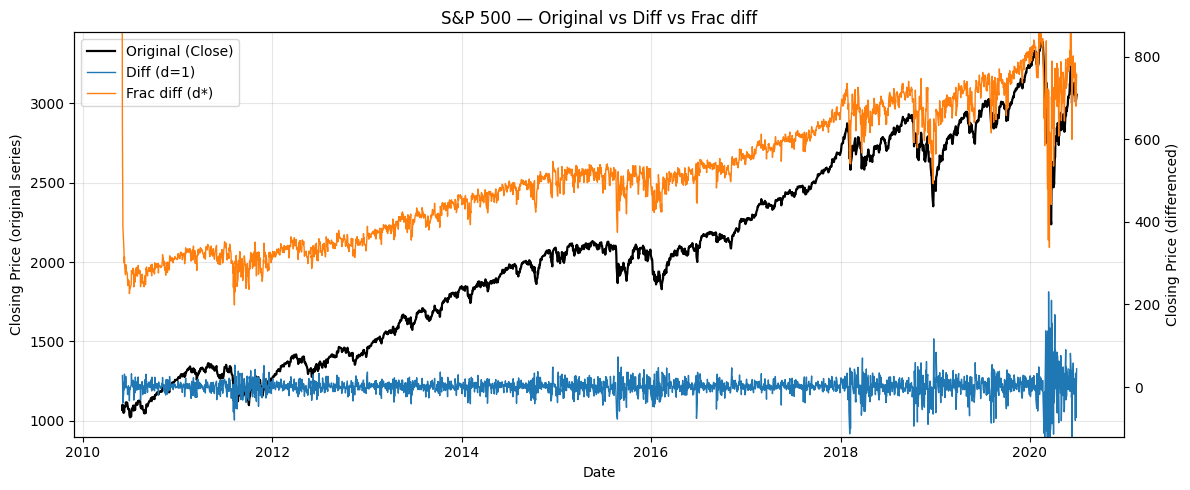

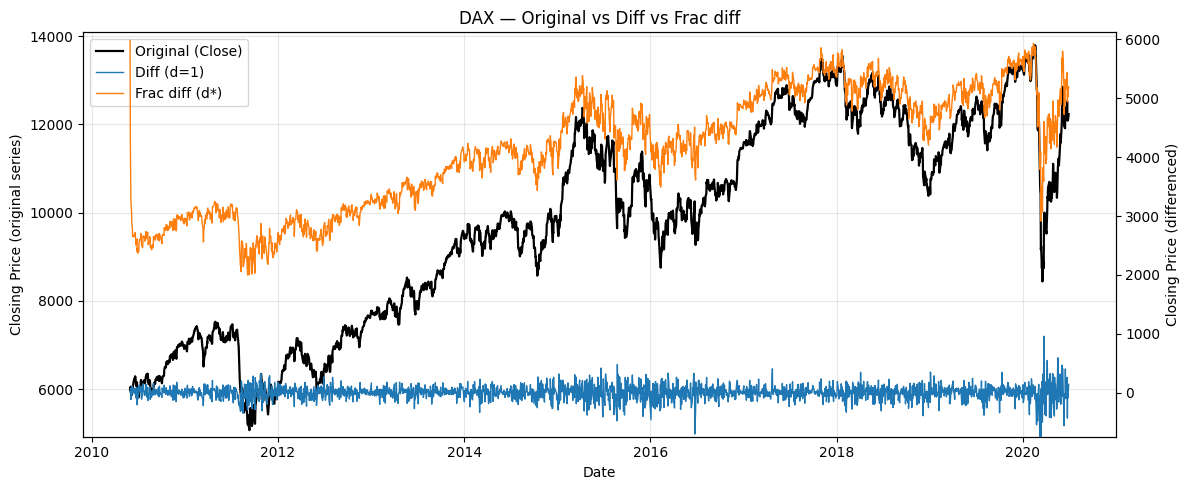

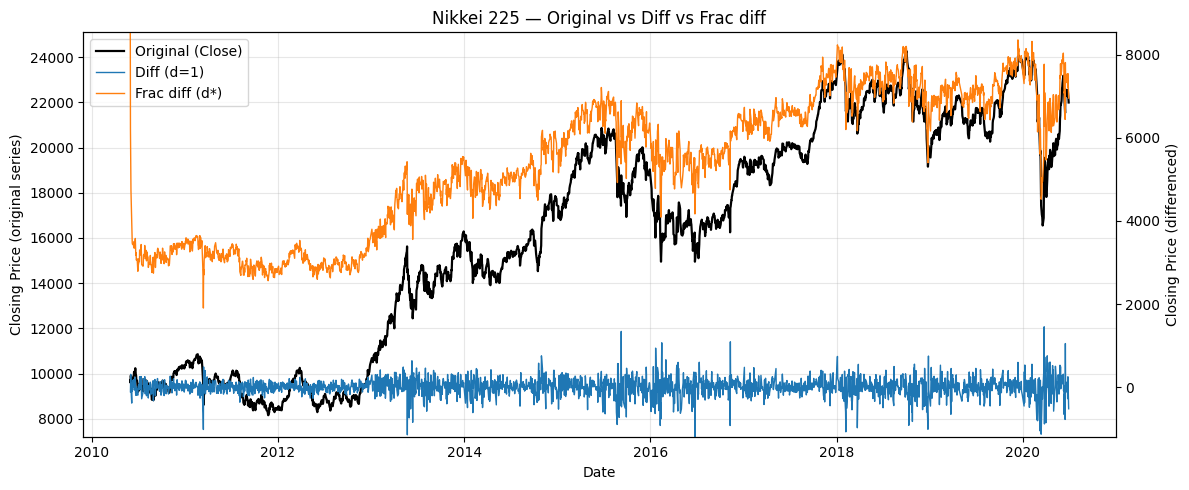

In [10]:
# === Combined visualization: original vs diff vs frac diff ===
plot_close_diff_frac_one("S&P 500 — Original vs Diff vs Frac diff", sp500)
plot_close_diff_frac_one("DAX — Original vs Diff vs Frac diff", dax)
plot_close_diff_frac_one("Nikkei 225 — Original vs Diff vs Frac diff", nikkei)


### ADF test statistics for various fractional orders of differencing

We now test a range of fractional orders \( d \in \{0.1, 0.2, \ldots, 0.9\} \) to identify the smallest value that yields (near-)stationarity for each index.

In [11]:
def sweep_fractional_orders(series, d_list):
    """
    For a given Series, compute fractional differences for each d in d_list.
    Returns a list of dict rows with stats + the transformed series.
    """
    rows = []
    for d in d_list:
        frac = Fracdiff(d)
        X = series[['Close']]          
        X_fd = frac.fit_transform(X)
        s_fd = pd.Series(X_fd.ravel(), index=series.index)        # re-align to original index (leading NaNs)
        a_stat, a_p, k_stat, k_p = stationarity_values(s_fd)
        rows.append({
            "d": d, "series": s_fd,
            "adf_stat": a_stat, "adf_p": a_p,
            "kpss_stat": k_stat, "kpss_p": k_p
        })
    return rows



In [12]:
# === Sweep d for each index and summarize ===
d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


summary_tables = {}

for name, df in {
    "S&P 500": sp500,
    "DAX": dax,
    "Nikkei 225": nikkei,
}.items():
    rows = sweep_fractional_orders(df, d_grid)  # expects a Series
    table_rows = []
    for r in rows:
        table_rows.append((
            f"d = {r['d']:.1f}",
            f"{r['adf_stat']:.2f}\n({r['adf_p']:.3f})",
            f"{r['kpss_stat']:.2f}\n({r['kpss_p']:.3f})",
        ))
    tbl = pd.DataFrame(table_rows, columns=["Order d", "ADF", "KPSS"]).set_index("Order d")
    summary_tables[name] = tbl

# Display tables
for name, tbl in summary_tables.items():
    print(f"=== {name} — fractional differencing sweep ===")
    display(tbl.style.set_properties(**{'white-space': 'pre-wrap'}))

/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in th

=== S&P 500 — fractional differencing sweep ===


/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(
/Users/fp/venvs/finance39/lib/python3.9/site-packages/statsmodels/tsa/stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in th

,ADF,KPSS
Order d,,
d = 0.1,-0.75 (0.832),8.03 (0.010)
d = 0.2,-0.71 (0.844),8.02 (0.010)
d = 0.3,-0.75 (0.834),8.00 (0.010)
d = 0.4,-0.83 (0.811),7.97 (0.010)
d = 0.5,-0.97 (0.763),7.92 (0.010)
d = 0.6,-1.24 (0.657),7.82 (0.010)
d = 0.7,-1.74 (0.411),7.85 (0.010)
d = 0.8,-2.79 (0.060),7.68 (0.010)
d = 0.9,-5.56 (0.000),5.98 (0.010)


=== DAX — fractional differencing sweep ===


,ADF,KPSS
Order d,,
d = 0.1,-1.67 (0.448),7.32 (0.010)
d = 0.2,-1.66 (0.454),7.29 (0.010)
d = 0.3,-1.80 (0.383),7.26 (0.010)
d = 0.4,-1.88 (0.343),7.20 (0.010)
d = 0.5,-1.87 (0.344),7.10 (0.010)
d = 0.6,-2.16 (0.220),7.13 (0.010)
d = 0.7,-2.58 (0.098),6.91 (0.010)
d = 0.8,-3.77 (0.003),6.43 (0.010)
d = 0.9,-7.72 (0.000),3.19 (0.010)


=== Nikkei 225 — fractional differencing sweep ===


,ADF,KPSS
Order d,,
d = 0.1,-1.18 (0.684),7.30 (0.010)
d = 0.2,-1.12 (0.707),7.29 (0.010)
d = 0.3,-1.19 (0.677),7.26 (0.010)
d = 0.4,-1.37 (0.597),7.22 (0.010)
d = 0.5,-1.60 (0.482),7.38 (0.010)
d = 0.6,-1.53 (0.518),7.25 (0.010)
d = 0.7,-2.00 (0.287),7.19 (0.010)
d = 0.8,-3.04 (0.032),7.00 (0.010)
d = 0.9,-8.07 (0.000),4.74 (0.010)


> **Personal observation:**
> From the combined evidence of the ADF and KPSS tests, we can infer that the optimal degree of fractional differencing is roughly **0.6–0.7** for the S&P 500, **0.0–0.1** for the DAX, and **0.4–0.5** for the Nikkei 225.
> These ranges indicate that each index requires a different level of memory adjustment to achieve (near-)stationarity.

## Creating the dataset for the NN 